In [16]:
# Dual-layer Statistical Analysis - participant data

import seaborn as sns
import pandas as pd
import os
import pingouin as pg
import matplotlib.pyplot as plt
import numpy as np
import ptitprince as pt

# Preparations ---------------------------------------------------------------

file_path = "C:/Users/melan/Desktop/duallayer_stats/"
pathout = 'C:/Users/melan/Desktop/duallayer_stats/results/'
os.chdir(file_path)

my_palette = ['#EC5800', '#0F52BA']

df = pd.read_csv(os.path.join(file_path, 'ERP_stats.txt'), sep=",")
df = df.drop([0])


In [17]:
# Prepare data - SNR

df_long = pd.melt(df, id_vars=["ID"], value_vars= ['ICC_tar_stand_SNR', 'ICC_tar_walk_SNR',
                                                   'trad_tar_stand_SNR', 'trad_tar_walk_SNR'],
                  var_name = "Cond", value_name="SNR")


# split Cond into parts
df_long[["pipeline", "ignore", "motion", "ignore2"]] = df_long["Cond"].str.split("_", expand=True)

# keep only pipeline + motion
df_long = df_long.drop(columns=["ignore", "ignore2"])

df_long["pipeline"] = df_long["Cond"].str.split("_").str[0]
df_long["motion"] = df_long["Cond"].str.split("_").str[2]


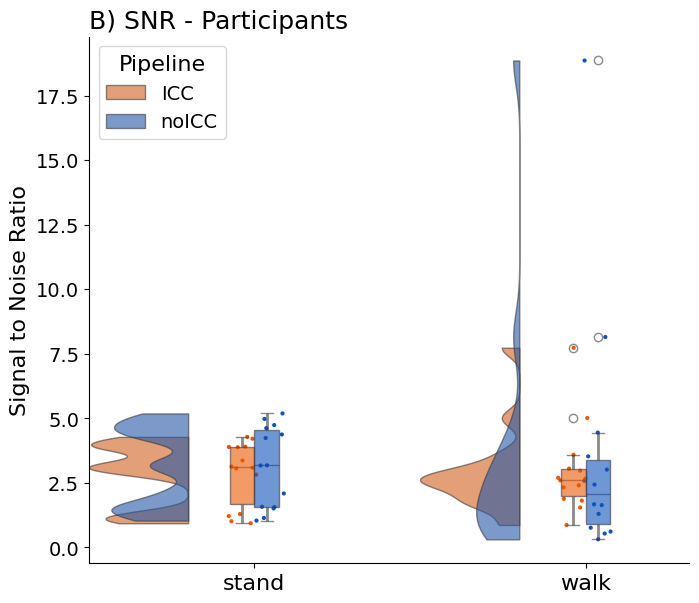

In [ ]:
# Plot data - SNR

fig1, ax = plt.subplots(figsize=(8,6))

pt.RainCloud(
    data=df_long,
    x="motion",
    y="SNR",
    hue="pipeline",
    palette=my_palette,
    dodge=True,
    width_viol=.6,
    alpha=.6,
    orient="v",
    ax=ax
)

sns.despine()
plt.tight_layout()


plt.ylabel("Signal to Noise Ratio", fontsize=16)
plt.xlabel("", fontsize=10)
plt.title("B) SNR - Participants", loc='left', fontsize = 18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=14)
ax.legend(title="Pipeline", labels=["ICC", "noICC"], fontsize=14, title_fontsize=16)

os.chdir(pathout)
fig1.savefig("participants_SNR.png", dpi=300, bbox_inches='tight')
fig1.savefig("participants_SNR.svg", dpi=300, bbox_inches='tight')

In [ ]:
# Stats - SNR

stats = (
    df_long.groupby(['pipeline', 'motion'])['SNR']
      .agg(mean='mean', sd='std', n='count')
      .reset_index()
)

print(stats)

my_aov = pg.rm_anova(data = df_long, dv = 'SNR',  within = ['pipeline', 'motion'],
                        subject = 'ID')
print(my_aov.round(3))


'''            Source   SS    ddof1  ddof2   MS    F     p-unc  p-GG-corr  \
0           pipeline  2.583      1     13  2.583  0.691  0.421      0.421   
1             motion  1.011      1     13  1.011  0.131  0.723      0.723   
2  pipeline * motion  0.516      1     13  0.516  0.168  0.688      0.688   

     ng2  eps  
0  0.006  1.0  
1  0.003  1.0  
2  0.001  1.0  '''

              Source     SS  ddof1  ddof2     MS      F  p-unc  p-GG-corr  \
0           pipeline  2.583      1     13  2.583  0.691  0.421      0.421   
1             motion  1.011      1     13  1.011  0.131  0.723      0.723   
2  pipeline * motion  0.516      1     13  0.516  0.168  0.688      0.688   

     ng2  eps  
0  0.006  1.0  
1  0.003  1.0  
2  0.001  1.0  


c:\Users\melan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\melan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


'            Source   SS    ddof1  ddof2   MS    F     p-unc  p-GG-corr  0           pipeline  2.583      1     13  2.583  0.691  0.421      0.421   \n1             motion  1.011      1     13  1.011  0.131  0.723      0.723   \n2  pipeline * motion  0.516      1     13  0.516  0.168  0.688      0.688   \n\n     ng2  eps  \n0  0.006  1.0  \n1  0.003  1.0  \n2  0.001  1.0  '

In [19]:
# Prepare data - ERPs

df_long = pd.melt(df, id_vars=["ID"], value_vars= ['ICC_tar_stand_amp', 'ICC_tar_walk_amp',
                                                   'trad_tar_stand_amp', 'trad_tar_walk_amp',
                                                   'ICC_sta_stand_amp', 'ICC_sta_walk_amp',
                                                   'trad_sta_stand_amp', 'trad_sta_walk_amp'],
                  var_name = "Cond", value_name="Amp")


# split Cond into parts
df_long[["pipeline", "ignore", "motion", "ignore2"]] = df_long["Cond"].str.split("_", expand=True)

# keep only pipeline + motion
df_long = df_long.drop(columns=["ignore", "ignore2"])

df_long["pipeline"] = df_long["Cond"].str.split("_").str[0]
df_long["stimulus"] = df_long["Cond"].str.split("_").str[1]
df_long["motion"]   = df_long["Cond"].str.split("_").str[2]

df_sum = df_long[df_long['stimulus'] == 'tar']
df_sum['oddball_effect'] = np.array(df_long[df_long['stimulus'] == 'tar']['Amp']) - np.array(df_long[df_long['stimulus'] == 'sta']['Amp'])

C:\Users\melan\AppData\Local\Temp\ipykernel_23428\3383466094.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sum['oddball_effect'] = np.array(df_long[df_long['stimulus'] == 'tar']['Amp']) - np.array(df_long[df_long['stimulus'] == 'sta']['Amp'])


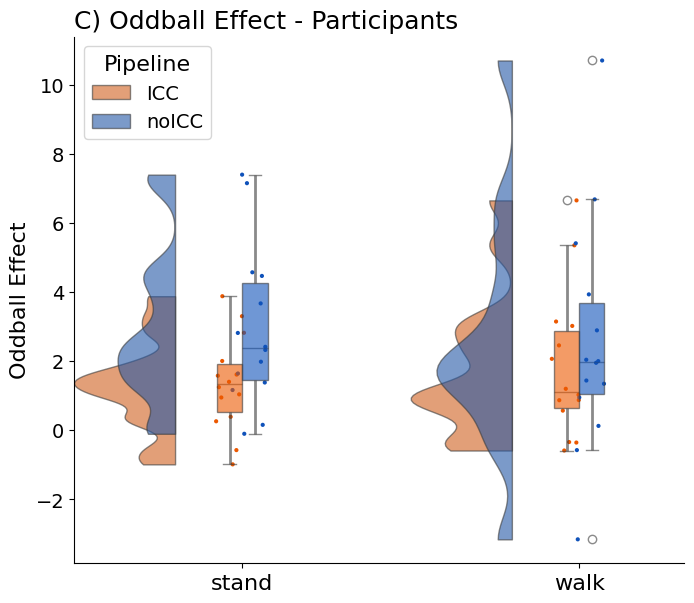

In [20]:
# Plot data - ERPs

fig2, ax = plt.subplots(figsize=(8,6))

pt.RainCloud(
    data=df_sum,
    x="motion",
    y="oddball_effect",
    hue="pipeline",
    palette=my_palette,
    dodge=True,
    width_viol=.6,
    alpha=.6,
    orient="v",
    ax=ax
)

sns.despine()
plt.tight_layout()

plt.ylabel("Oddball Effect", fontsize=16)
plt.xlabel("", fontsize=10)
plt.title("C) Oddball Effect - Participants", loc='left', fontsize = 18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=14)
ax.legend(title="Pipeline", labels=["ICC", "noICC"], fontsize=14, title_fontsize=16)

os.chdir(pathout)
fig2.savefig("participants_oddball.png", dpi=300, bbox_inches='tight')
fig2.savefig("participants_oddball.svg", dpi=300, bbox_inches='tight')




In [ ]:
# Stats - ERPs

stats = (
    df_sum.groupby(['pipeline', 'motion'])['oddball_effect']
      .agg(mean='mean', sd='std', n='count')
      .reset_index()
)

print(stats)


my_aov = pg.rm_anova(data = df_sum, dv = 'Amp',  within = ['pipeline', 'motion'],
                        subject = 'ID')
print(my_aov.round(3))

'''           Source      SS  ddof1  ddof2    MS       F    p-unc  p-GG-corr  \
0           pipeline  20.098      1     13  20.098  12.365  0.004      0.004   
1             motion   1.034      1     13   1.034   0.419  0.529      0.529   
2  pipeline * motion   0.340      1     13   0.340   0.453  0.513      0.513   

     ng2  eps  
0  0.067  1.0  
1  0.004  1.0  
2  0.001  1.0   '''


              Source      SS  ddof1  ddof2      MS       F  p-unc  p-GG-corr  \
0           pipeline  20.098      1     13  20.098  12.365  0.004      0.004   
1             motion   1.034      1     13   1.034   0.419  0.529      0.529   
2  pipeline * motion   0.340      1     13   0.340   0.453  0.513      0.513   

     ng2  eps  
0  0.067  1.0  
1  0.004  1.0  
2  0.001  1.0  


c:\Users\melan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\melan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


'           Source      SS  ddof1  ddof2    MS       F    p-unc  p-GG-corr  0           pipeline  20.098      1     13  20.098  12.365  0.004      0.004   \n1             motion   1.034      1     13   1.034   0.419  0.529      0.529   \n2  pipeline * motion   0.340      1     13   0.340   0.453  0.513      0.513   \n\n     ng2  eps  \n0  0.067  1.0  \n1  0.004  1.0  \n2  0.001  1.0   '

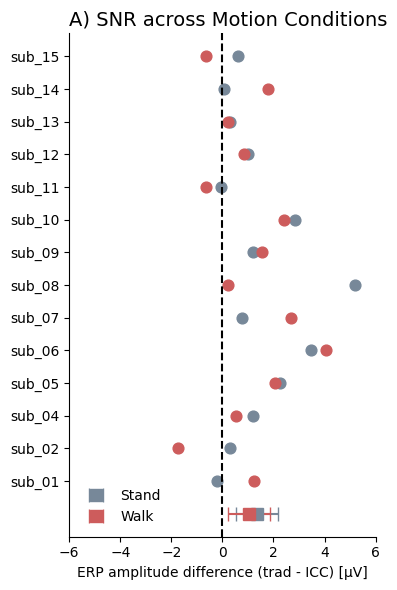

In [8]:
# Subject-wise differences

df['diff_stand'] = df['trad_tar_stand_amp'] - df['ICC_tar_stand_amp']
df['diff_walk'] = df['trad_tar_walk_amp'] - df['ICC_tar_walk_amp']

mean_diff_stand = df['diff_stand'].mean()
sem_diff_stand = df['diff_stand'].std(ddof=1) / np.sqrt(len(df))

mean_diff_walk = df['diff_walk'].mean()
sem_diff_walk = df['diff_walk'].std(ddof=1) / np.sqrt(len(df))

ci95 = 1.96 * sem_diff_stand

# Optional: repeated-measures Cohen's dz
cohens_dz_stand = mean_diff_stand / df['diff_stand'].std(ddof=1)
cohens_dz_walk = mean_diff_walk / df['diff_walk'].std(ddof=1)


my_y = np.arange(len(df))
fig, ax = plt.subplots(figsize=(4,6))

# -------------------------------------------------------
# Standing points
# -------------------------------------------------------

ax.scatter(
    df['diff_stand'],
    my_y,
    s=60,
    color = 'lightslategray'
)

# -------------------------------------------------------
# Walking points
# -------------------------------------------------------

ax.scatter(
    df['diff_walk'],
    my_y,
    s=60,
    color = 'indianred'
)

# -------------------------------------------------------
# Zero reference line
# -------------------------------------------------------

ax.axvline(0, linestyle='--', color = 'k')

# Overall effect at bottom
ax.errorbar(
    x = mean_diff_stand,
    y = -1,
    xerr=ci95,
    fmt='s',
    capsize=5,
    color = 'lightslategray',
    markersize=8,
    label='Stand'
)

ax.errorbar(
    x = mean_diff_walk,
    y = -1,
    xerr=ci95,
    fmt='s',
    capsize=5,
    color = 'indianred',
    markersize=8,
    label='Walk'
)

# -------------------------------------------------------
# Labels
# -------------------------------------------------------

ax.set_yticks(my_y)
ax.set_yticklabels(df['ID'])

ax.set_xlabel('ERP amplitude difference (trad - ICC) [µV]')
ax.set_ylabel('')

plt.title("A) SNR across Motion Conditions", loc='left', fontsize = 14)

ax.legend(frameon=False, loc = 'lower left')

# Optional axis limits
ax.set_xlim(-6, 6)

#ax.text(
#    0.02,
#    0.85,
#    f"\u0394 stand = {mean_diff_stand:.2f} µV\n"
#    f"\u0394 walk = {mean_diff_walk:.2f} µV\n",
#    transform=ax.transAxes,
#    verticalalignment='bottom'
#)


# Cleaner appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


os.chdir(pathout)
fig.savefig("participants_pipelineComp_diffs.svg", dpi=300, bbox_inches='tight')



In [23]:
#%% percent change

df['perc_diff_stand'] = (
    (df['trad_tar_stand_amp'] - df['ICC_tar_stand_amp']) /
    (
        (np.abs(df['trad_tar_stand_amp']) +
         np.abs(df['ICC_tar_stand_amp'])) / 2
    )
) * 100

df['perc_diff_walk'] = (
    (df['trad_tar_walk_amp'] - df['ICC_tar_walk_amp']) /
    (
        (np.abs(df['trad_tar_walk_amp']) +
         np.abs(df['ICC_tar_walk_amp'])) / 2
    )
) * 100


mean_perc_diff_stand = df['perc_diff_stand'].mean()
mean_perc_diff_walk = df['perc_diff_walk'].mean()

sem_perc_stand = df['perc_diff_stand'].std(ddof=1) / np.sqrt(len(df))
sem_perc_walk = df['perc_diff_walk'].std(ddof=1) / np.sqrt(len(df))
ci95_perc_stand = 1.96 * sem_perc_stand
ci95_perc_walk = 1.96 * sem_perc_walk


cohens_dz_perc_stand = (
    mean_perc_diff_stand /
    df['perc_diff_stand'].std(ddof=1)
)

cohens_dz_perc_walk = (
    mean_perc_diff_walk /
    df['perc_diff_walk'].std(ddof=1)
)

print(f"Cohen's dz (percent difference stand): {cohens_dz_perc_stand:.3f}")
print(f"Cohen's dz (percent difference walk): {cohens_dz_perc_walk:.3f}")

Cohen's dz (percent difference stand): 0.888
Cohen's dz (percent difference walk): 0.393


In [21]:
# Load and prepare data - ICs

df = pd.read_csv(os.path.join(file_path, 'COMP_stats.txt'), sep=",") # Adjust sep as needed

df = df.drop([0,3,16,19])
# use a dedicated dataframe name to avoid clobbering df_long used elsewhere
df_comp = pd.melt(df, id_vars=["ID", "Pipeline"], value_vars=['brain', 'eye', 'muscle', 'other'],
                  var_name="Component", value_name="Number")

c:\Users\melan\AppData\Local\Programs\Python\Python313\Lib\site-packages\ptitprince\PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):


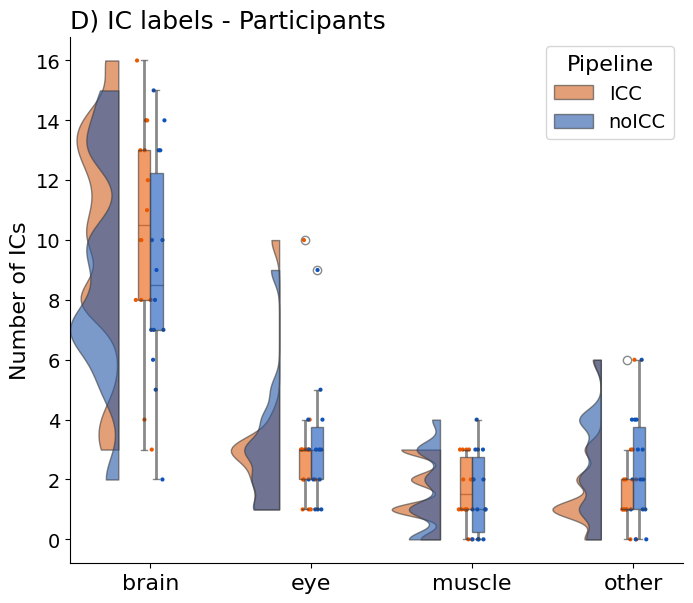

In [22]:
# Plot data - iCs

df_comp["Pipeline"] = pd.Categorical(df_comp["Pipeline"], categories=["ICC", "trad"], ordered=True)

fig3, ax = plt.subplots(figsize=(8,6))

pt.RainCloud(
    data=df_comp,
    x="Component",
    y="Number",
    hue="Pipeline",
    palette=my_palette,
    dodge=True,
    width_viol=.6,
    alpha=.6,
    orient="v",
    ax=ax
)

sns.despine()
plt.tight_layout()

plt.ylabel("Number of ICs", fontsize=16)
plt.xlabel("", fontsize=10)
plt.title("D) IC labels - Participants", loc='left', fontsize = 18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=14)
ax.legend(title="Pipeline", labels=["ICC", "noICC"], fontsize=14, title_fontsize=16)

os.chdir(pathout)
fig3.savefig("participants_ICA.png", dpi=300, bbox_inches='tight')
fig3.savefig("participants_ICA.svg", dpi=300, bbox_inches='tight')

In [ ]:
# Stats - ICs

stats = (
    df_comp.groupby(['Pipeline', 'Component'])['Number']
      .agg(mean='mean', sd='std', n='count')
      .reset_index()
)

print(stats)


results = []

# for these components a decrease in ICC is considered "positive" (matches color mapping)
invert_components = {'eye', 'muscle', 'other'}

for dv in ['brain', 'eye', 'muscle', 'other']:
    # choose one-sided direction consistent with the plotting logic:
    # - brain: test ICC > trad  -> tail='greater'
    # - eye/muscle/other: test ICC < trad -> tail='less'
    tail = 'greater' if dv not in invert_components else 'less'
    res = pg.pairwise_tests(dv=dv, between='Pipeline', data=df, alternative=tail)
    res['DV'] = dv
    res['tail'] = tail
    results.append(res)

all_results = pd.concat(results, ignore_index=True)

# apply Holm correction across the uncorrected p-values
all_results['p-corr'] = pg.multicomp(all_results['p-unc'].values, method='holm')[1]

df_long = df.melt(id_vars=["ID", "Pipeline"], 
                  value_vars=["brain", "eye", "muscle", "other"],
                  var_name="Component", 
                  value_name="Value")

print(all_results)


''''Contrast  A     B    Paired    Parametric   T     dof alternative  \
0  Pipeline  ICC  trad   False        True  0.903132  26.0     greater   
1  Pipeline  ICC  trad   False        True -0.174587  26.0        less   
2  Pipeline  ICC  trad   False        True  0.309743  26.0        less   
3  Pipeline  ICC  trad   False        True -1.036048  26.0        less   

      p-unc   BF10    hedges      DV     tail    p-corr  
0  0.187374  0.958  0.331409   brain  greater  0.619441  
1  0.431378  0.715 -0.064066     eye     less  0.862756  
2  0.620387  0.732  0.113662  muscle     less  0.862756  
3  0.154860  1.054 -0.380184   other     less  0.619441'''

In [ ]:
# additional analysis: correlations (?)

from scipy.stats import pearsonr

# -------------------------------------------------------
# Variables
# -------------------------------------------------------

x = df['all_mean_corrs']

y_stand = df['diff_stand']
y_walk = df['diff_walk']

subjects = df['ID']

# -------------------------------------------------------
# Correlations
# -------------------------------------------------------

r_stand, p_stand = pearsonr(x, y_stand)
r_walk, p_walk = pearsonr(x, y_walk)

# -------------------------------------------------------
# Generate participant colors
# -------------------------------------------------------

cmap = plt.cm.tab20
colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

# -------------------------------------------------------
# Figure
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

conditions = [
    (y_stand, r_stand, p_stand, 'Standing'),
    (y_walk, r_walk, p_walk, 'Walking')
]

for ax, (y, r, p, title) in zip(axes, conditions):

    # ---------------------------------------------------
    # Participant-wise scatter
    # ---------------------------------------------------

    for i in range(len(df)):

        ax.scatter(
            x.iloc[i],
            y.iloc[i],
            s=70,
            color=colors[i]
        )

    # ---------------------------------------------------
    # Regression line
    # ---------------------------------------------------

    m, b = np.polyfit(x, y, 1)

    xx = np.linspace(x.min(), x.max(), 100)

    ax.plot(xx, m * xx + b, 'k', linewidth=2)

    # ---------------------------------------------------
    # Labels
    # ---------------------------------------------------

    ax.set_title(title)
    ax.set_ylim(-2, 6)
    ax.set_xlabel('Mean scalp–noise correlation')

    ax.text(
        0.8,
        0.95,
        f'r = {r:.2f}\np = {p:.3f}',
        transform=ax.transAxes,
        verticalalignment='top'
    )

    # Cleaner appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('ERP difference (trad - iCC) [µV]')

plt.tight_layout()
plt.show()